Program 9: You have data on housing prices and square footage and notice that the relationship between square footage and price is nonlinear. Fit a spline regression model to allow the relationship between square footage and price to change at 2,000 square feet. Explain how spline regression can capture different behaviours of the relationship before and after 2,000 square feet. 

Spline Regression Coefficients
--------------------------------
Intercept          : -255734.82
SqFt coefficient   : 308.7
Spline coefficient : -73.58

Actual and Predicted Prices
   SqFt   Price  Predicted_Price
0  1500  200000    207318.105850
1  1600  250000    238188.300836
2  1800  300000    299928.690808
3  1900  320000    330798.885794
4  2000  350000    361669.080780
5  2100  400000    385181.058496
6  2200  420000    408693.036212
7  2400  450000    455716.991643
8  2600  500000    502740.947075
9  2800  550000    549764.902507


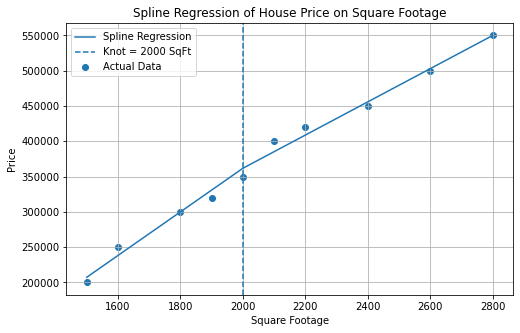


Explanation:
Spline regression uses a knot at 2000 square feet.
Before 2000 SqFt, the relationship follows one slope.
After 2000 SqFt, the spline term changes the slope.
Therefore, spline regression can model different behaviours
before and after the 2000 SqFt knot.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset
data = {
    'Price': [200000, 250000, 300000, 320000, 350000,
              400000, 420000, 450000, 500000, 550000],
    'SqFt': [1500, 1600, 1800, 1900, 2000,
             2100, 2200, 2400, 2600, 2800]
}

df = pd.DataFrame(data)

# Create spline term with knot at 2000 SqFt
df['Spline'] = np.maximum(0, df['SqFt'] - 2000)

# Independent variables
X = np.column_stack([
    np.ones(len(df)),
    df['SqFt'].values,
    df['Spline'].values
])

# Dependent variable
y = df['Price'].values

# Fit spline regression using least squares
coefficients = np.linalg.lstsq(X, y, rcond=None)[0]

# Calculate predicted prices
df['Predicted_Price'] = X @ coefficients

# Display coefficients
print("Spline Regression Coefficients")
print("--------------------------------")
print("Intercept          :", round(coefficients[0], 2))
print("SqFt coefficient   :", round(coefficients[1], 2))
print("Spline coefficient :", round(coefficients[2], 2))

# Display actual and predicted prices
print("\nActual and Predicted Prices")
print(df[['SqFt', 'Price', 'Predicted_Price']])

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    df['SqFt'].values,
    df['Price'].values,
    label='Actual Data'
)

plt.plot(
    df['SqFt'].values,
    df['Predicted_Price'].values,
    label='Spline Regression'
)

# Mark the knot
plt.axvline(
    x=2000,
    linestyle='--',
    label='Knot = 2000 SqFt'
)

plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.title('Spline Regression of House Price on Square Footage')
plt.legend()
plt.grid(True)
plt.show()

# Explanation
print("\nExplanation:")
print("Spline regression uses a knot at 2000 square feet.")
print("Before 2000 SqFt, the relationship follows one slope.")
print("After 2000 SqFt, the spline term changes the slope.")
print("Therefore, spline regression can model different behaviours")
print("before and after the 2000 SqFt knot.")